In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import regexp_replace, col
import seaborn as sns
from pyspark.sql.functions import col, count, isnan, when, corr, floor, ceil, regexp_replace, expr
import matplotlib.pyplot as plt
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

In [2]:
spark = SparkSession.builder \
    .appName("CSCI316_FINAL_PROJECT_LOAN") \
    .getOrCreate()

### Read the CSV
We start by loading the dataset and checking its dimensions — just to get a sense of how big it is and what we're dealing with. We also want to see which columns have a lot of nulls, since that'll affect what we can actually use.

In [3]:
df = spark.read.csv('data.csv', header=True, inferSchema=True)
print(f"shape: {df.count()} rows x {len(df.columns)} col")

shape: 855969 rows x 73 col


In [4]:
df.limit(100)

DataFrame[id: int, member_id: int, loan_amnt: int, funded_amnt: int, funded_amnt_inv: double, term: string, int_rate: double, installment: double, grade: string, sub_grade: string, emp_title: string, emp_length: string, home_ownership: string, annual_inc: string, verification_status: string, issue_d: string, pymnt_plan: string, desc: string, purpose: string, title: string, zip_code: string, addr_state: string, dti: string, delinq_2yrs: string, earliest_cr_line: string, inq_last_6mths: string, mths_since_last_delinq: string, mths_since_last_record: string, open_acc: string, pub_rec: string, revol_bal: string, revol_util: string, total_acc: string, initial_list_status: string, out_prncp: string, out_prncp_inv: string, total_pymnt: string, total_pymnt_inv: string, total_rec_prncp: string, total_rec_int: string, total_rec_late_fee: string, recoveries: string, collection_recovery_fee: string, last_pymnt_d: string, last_pymnt_amnt: string, next_pymnt_d: string, last_credit_pull_d: string, co

In [5]:
df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns])

DataFrame[id: bigint, member_id: bigint, loan_amnt: bigint, funded_amnt: bigint, funded_amnt_inv: bigint, term: bigint, int_rate: bigint, installment: bigint, grade: bigint, sub_grade: bigint, emp_title: bigint, emp_length: bigint, home_ownership: bigint, annual_inc: bigint, verification_status: bigint, issue_d: bigint, pymnt_plan: bigint, desc: bigint, purpose: bigint, title: bigint, zip_code: bigint, addr_state: bigint, dti: bigint, delinq_2yrs: bigint, earliest_cr_line: bigint, inq_last_6mths: bigint, mths_since_last_delinq: bigint, mths_since_last_record: bigint, open_acc: bigint, pub_rec: bigint, revol_bal: bigint, revol_util: bigint, total_acc: bigint, initial_list_status: bigint, out_prncp: bigint, out_prncp_inv: bigint, total_pymnt: bigint, total_pymnt_inv: bigint, total_rec_prncp: bigint, total_rec_int: bigint, total_rec_late_fee: bigint, recoveries: bigint, collection_recovery_fee: bigint, last_pymnt_d: bigint, last_pymnt_amnt: bigint, next_pymnt_d: bigint, last_credit_pull_d

In [6]:
df.dtypes

[('id', 'int'),
 ('member_id', 'int'),
 ('loan_amnt', 'int'),
 ('funded_amnt', 'int'),
 ('funded_amnt_inv', 'double'),
 ('term', 'string'),
 ('int_rate', 'double'),
 ('installment', 'double'),
 ('grade', 'string'),
 ('sub_grade', 'string'),
 ('emp_title', 'string'),
 ('emp_length', 'string'),
 ('home_ownership', 'string'),
 ('annual_inc', 'string'),
 ('verification_status', 'string'),
 ('issue_d', 'string'),
 ('pymnt_plan', 'string'),
 ('desc', 'string'),
 ('purpose', 'string'),
 ('title', 'string'),
 ('zip_code', 'string'),
 ('addr_state', 'string'),
 ('dti', 'string'),
 ('delinq_2yrs', 'string'),
 ('earliest_cr_line', 'string'),
 ('inq_last_6mths', 'string'),
 ('mths_since_last_delinq', 'string'),
 ('mths_since_last_record', 'string'),
 ('open_acc', 'string'),
 ('pub_rec', 'string'),
 ('revol_bal', 'string'),
 ('revol_util', 'string'),
 ('total_acc', 'string'),
 ('initial_list_status', 'string'),
 ('out_prncp', 'string'),
 ('out_prncp_inv', 'string'),
 ('total_pymnt', 'string'),
 ('t

## EDA
Before jumping into modelling, we explore the data visually to understand what's going on. Things like class imbalance, missing values, and how features relate to the target.

### Target Distribution
First thing we want to check is how balanced the target variable is. We plot the count of defaults vs non-defaults to see if there's an imbalance issue.

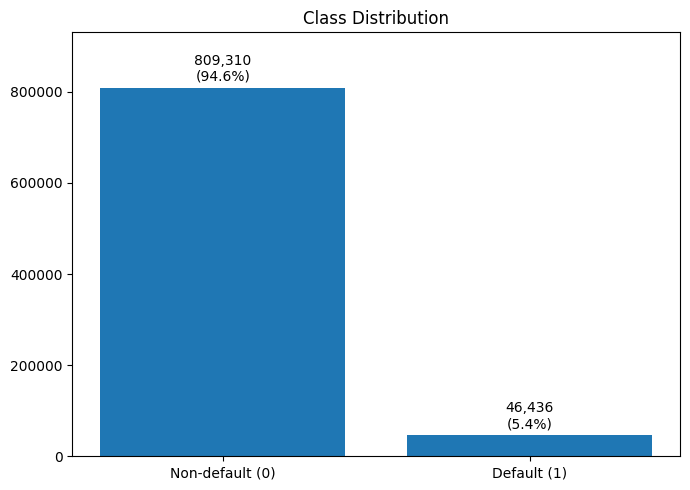

In [7]:
rows = df.filter(col('default_ind').isNotNull()).groupBy('default_ind').count().orderBy('default_ind').collect()
total = sum(r['count'] for r in rows)
labels = ['Non-default (0)' if r['default_ind'] == 0 else 'Default (1)' for r in rows]
counts = [r['count'] for r in rows]
pcts   = [r['count'] / total * 100 for r in rows]

plt.figure(figsize=(7, 5))
plt.bar(labels, counts)
for i, (c, p) in enumerate(zip(counts, pcts)):
    plt.text(i, c + max(counts) * 0.01, f'{c:,}\n({p:.1f}%)', ha='center', va='bottom')
plt.ylim(0, max(counts) * 1.15)
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

In [8]:
df.select('loan_amnt','int_rate','annual_inc','dti','revol_util',
            'installment','total_acc','open_acc').describe().show()

+-------+------------------+------------------+-----------------+------------------+--------------------+------------------+--------------------+-----------------+
|summary|         loan_amnt|          int_rate|       annual_inc|               dti|          revol_util|       installment|           total_acc|         open_acc|
+-------+------------------+------------------+-----------------+------------------+--------------------+------------------+--------------------+-----------------+
|  count|            855969|            855969|           855969|            855968|              855494|            855969|              855952|           855897|
|   mean|14745.571334943204|13.192319605031795|75071.22927176021|18.123810127573346|   55.91715695821084| 436.2380718343657|  25.968200584869795|11.54296815097585|
| stddev| 8425.340005005295| 4.368365181701452|64264.49486103647|17.425265176637353|  179.70164509533737|243.72687616798416|  163.67762776966018|5.312046264424071|
|    min|       

### Missing Values
Let's check how many nulls each column has. Some columns might be so sparse that keeping them doesn't make sense.

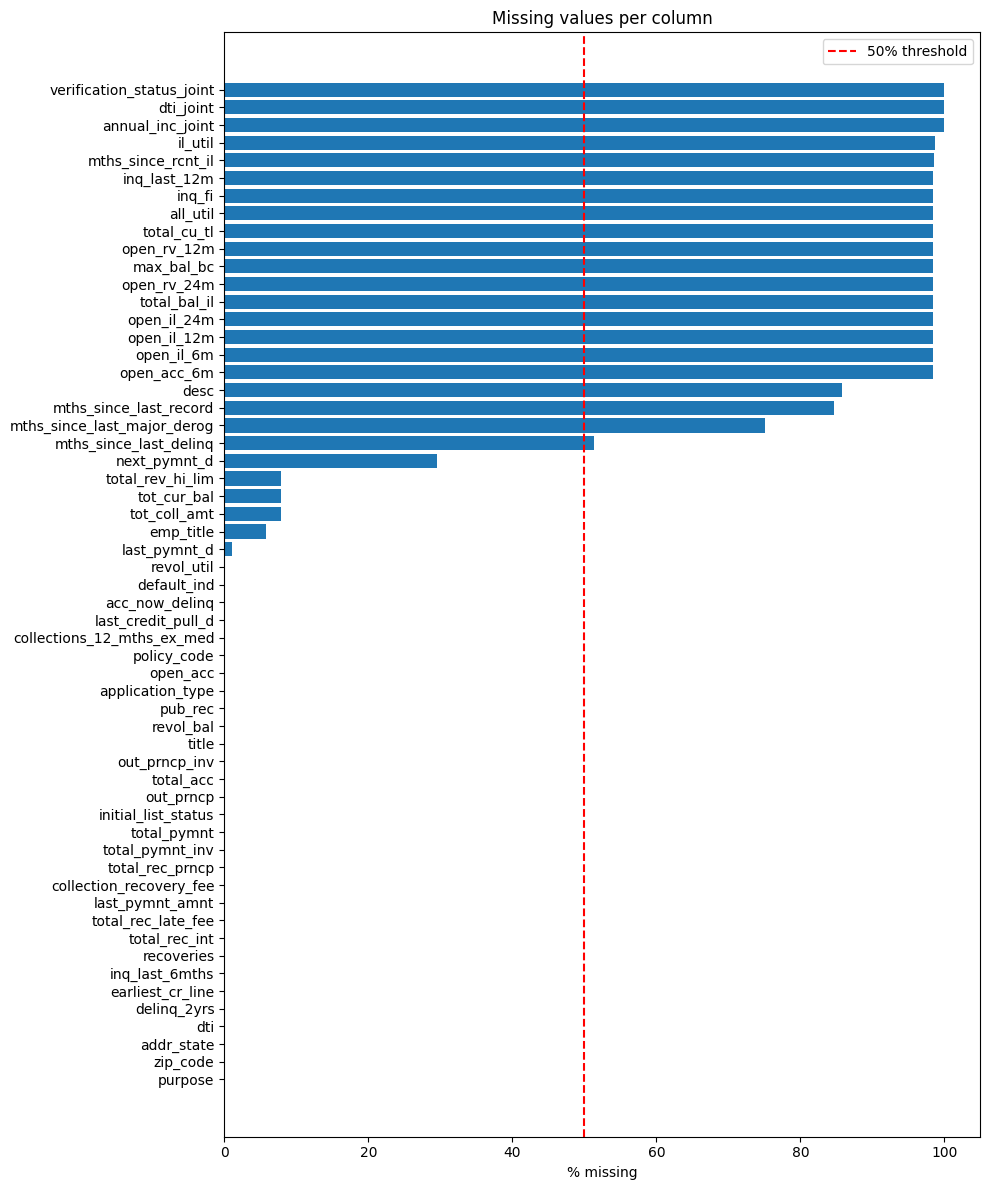

In [9]:
total = df.count()
missing_row = df.select([
    (count(when(col(c).isNull(), c)) / total * 100).alias(c)
    for c in df.columns
]).first().asDict()

missing_items = sorted(
    [(k, v) for k, v in missing_row.items() if v > 0],
    key=lambda x: x[1]
)

plt.figure(figsize=(10, 12))
plt.barh([x[0] for x in missing_items], [x[1] for x in missing_items])
plt.axvline(50, color='red', linestyle='--', label='50% threshold')
plt.xlabel('% missing')
plt.title('Missing values per column')
plt.legend()
plt.tight_layout()
plt.show()

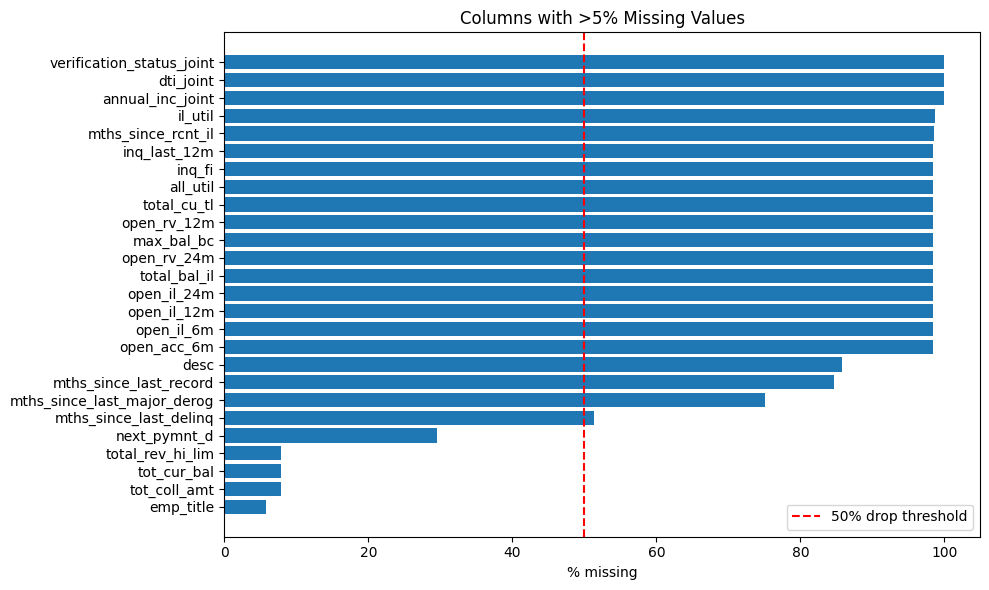

In [10]:
# Missing Values Visualization: More than 5% missing value
total = df.count()
missing_row = df.select([
    (count(when(col(c).isNull(), c)) / total * 100).alias(c)
    for c in df.columns
]).first().asDict()

missing_items = sorted(
    [(k, v) for k, v in missing_row.items() if v > 5],
    key=lambda x: x[1]
)

plt.figure(figsize=(10, 6))
plt.barh([x[0] for x in missing_items], [x[1] for x in missing_items])
plt.axvline(50, color='red', linestyle='--', label='50% drop threshold')
plt.xlabel('% missing')
plt.title('Columns with >5% Missing Values')
plt.legend()
plt.tight_layout()
plt.show()

### Correlation Heatmap
We compute a correlation matrix across numeric features to spot any obvious relationships and more importantly, to catch features that might be leaking the target.

In [11]:
numeric_types = {"int", "bigint", "float", "double"}
numeric_cols = [f.name for f in df.schema.fields if f.dataType.simpleString() in numeric_types]
print(numeric_cols)

['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'inq_last_12m', 'default_ind']


In [12]:
to_numeric = [
      'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq',
      'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal',
      'total_acc', 'collections_12_mths_ex_med', 'mths_since_last_major_derog',
      'acc_now_delinq', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
      'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
      'recoveries', 'collection_recovery_fee', 'last_pymnt_amnt',
      'policy_code', 'annual_inc_joint', 'dti_joint', 'tot_coll_amt', 'tot_cur_bal', 
      'total_rev_hi_lim','open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m',
      'mths_since_rcnt_il', 'total_bal_il', 'il_util',
      'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util',
      'inq_fi', 'total_cu_tl',
  ]

for c in to_numeric:
    df = df.withColumn(c, expr(f"try_cast({c} as double)"))

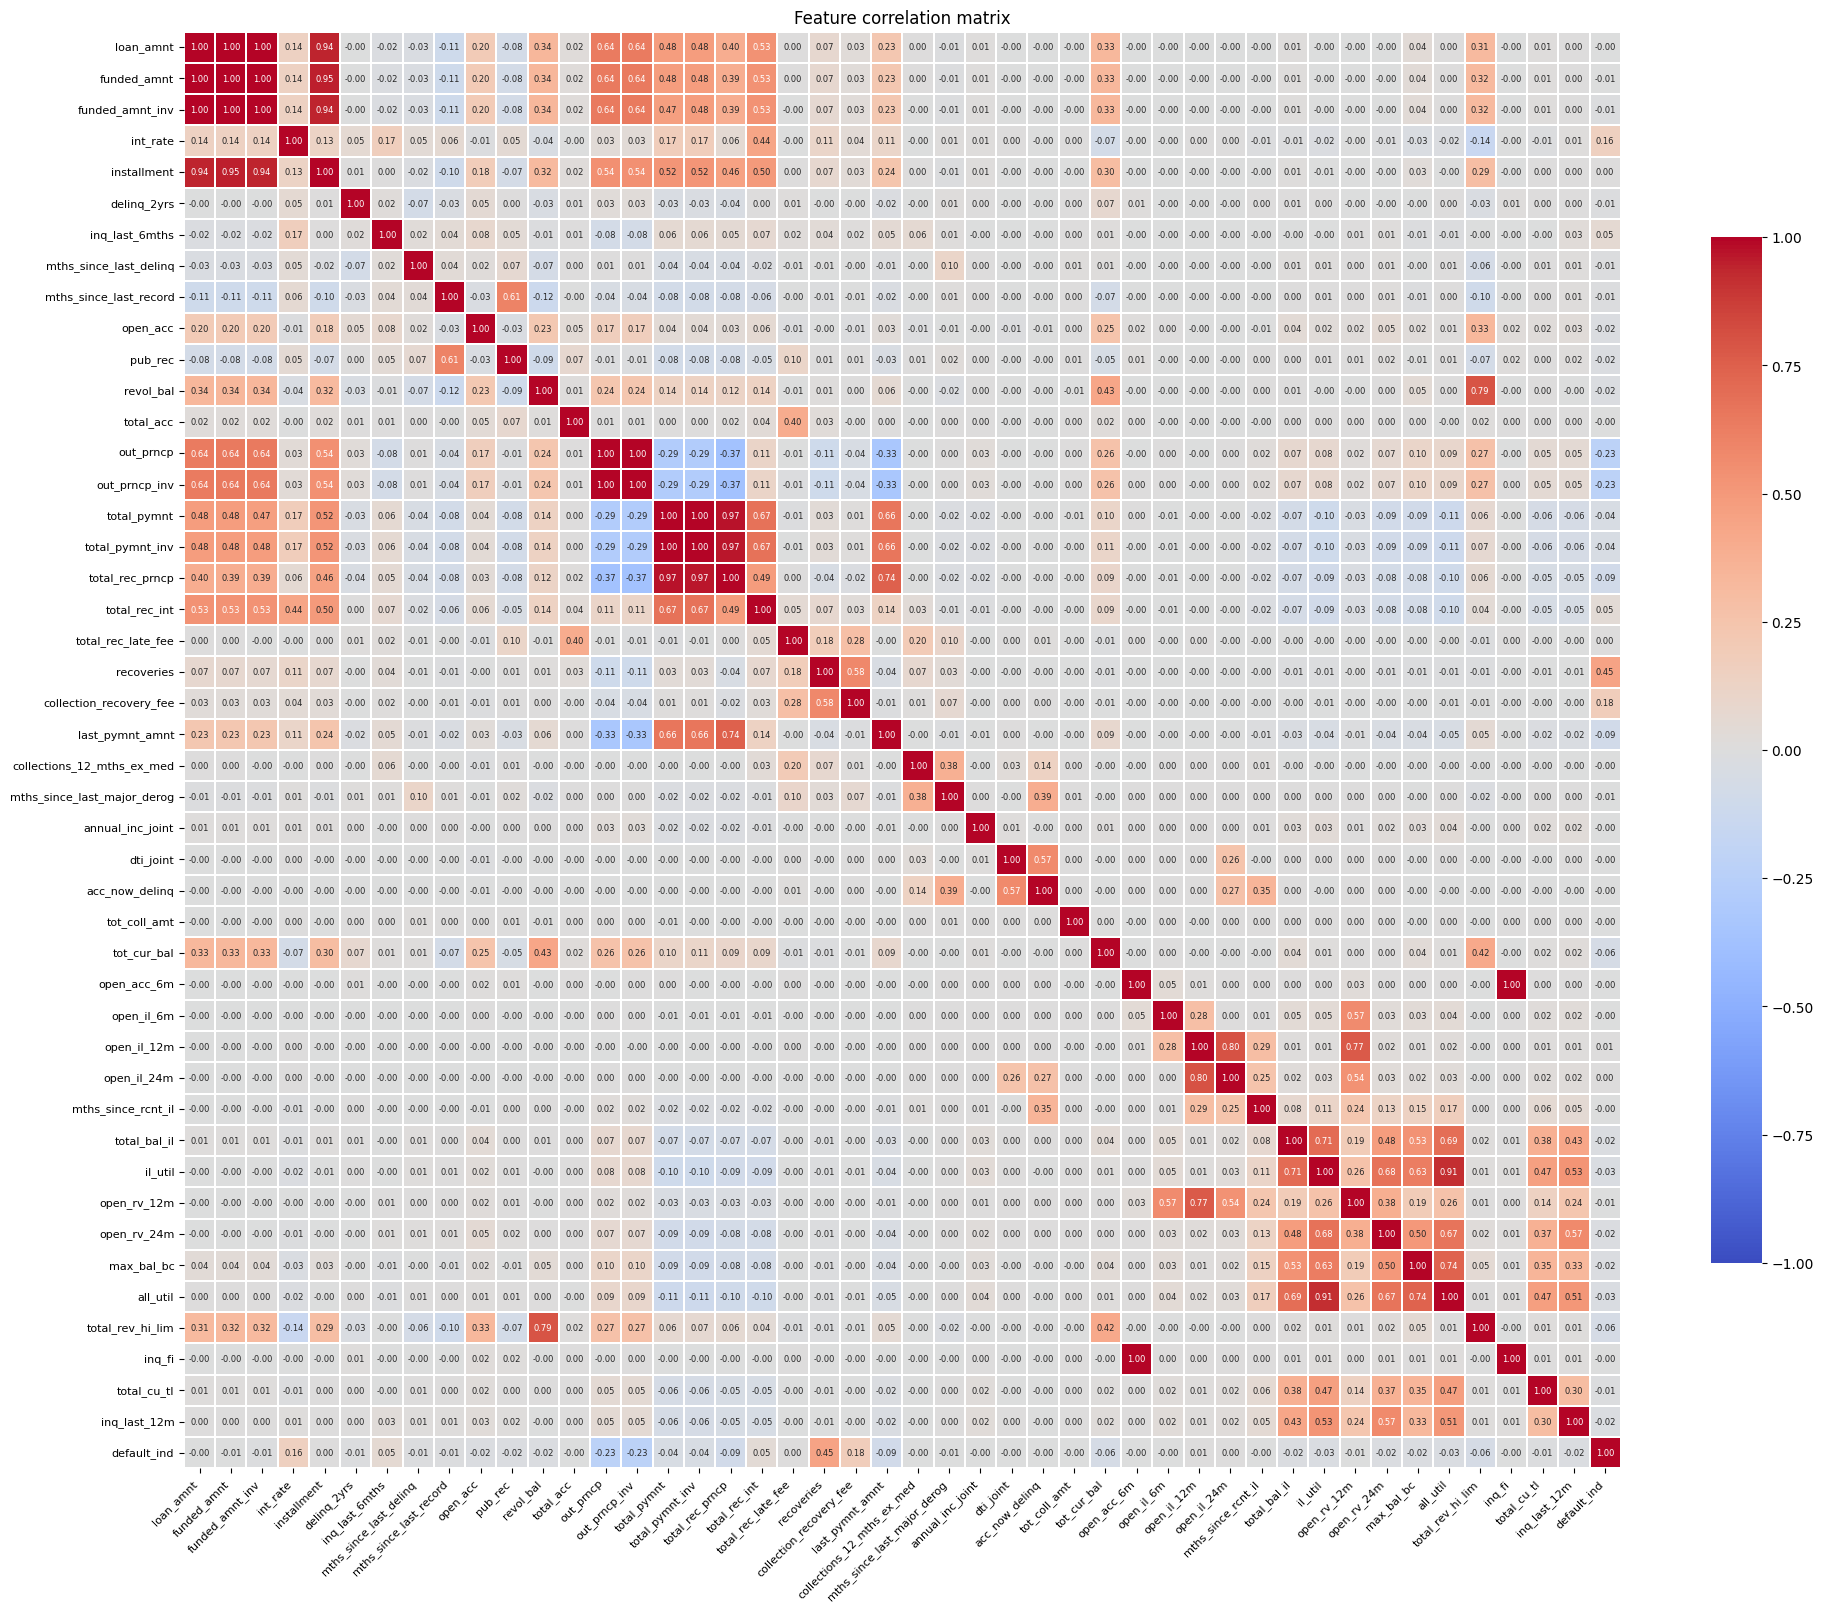

In [13]:
numeric_cols = [c for c, t in df.dtypes if t in ('int','bigint','double','float')]
numeric_cols = [c for c in numeric_cols if c not in ('id','member_id','policy_code')]

df_numeric = df.select(*numeric_cols).na.fill(0)
assembler = VectorAssembler(inputCols=numeric_cols, outputCol='features')
corr_matrix = Correlation.corr(
    assembler.transform(df_numeric).select('features'), 'features'
).head()[0].toArray()

plt.figure(figsize=(20, 18))     
sns.heatmap(
    corr_matrix,
    xticklabels=numeric_cols,
    yticklabels=numeric_cols,
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True,                 
    annot=True, fmt='.2f',       
    annot_kws={'size': 6},        
    cbar_kws={'shrink': 0.6},     
    linewidths=0.3, linecolor='white'
)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.title('Feature correlation matrix', fontsize=12)
plt.tight_layout()
plt.show()

### Numeric Features vs Target
Here we look at how individual numeric features are distributed across defaulters vs non-defaulters.

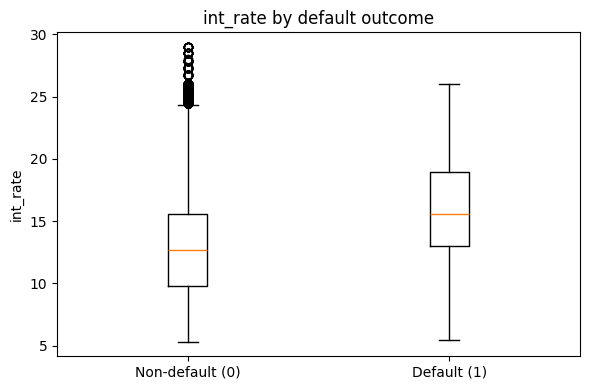

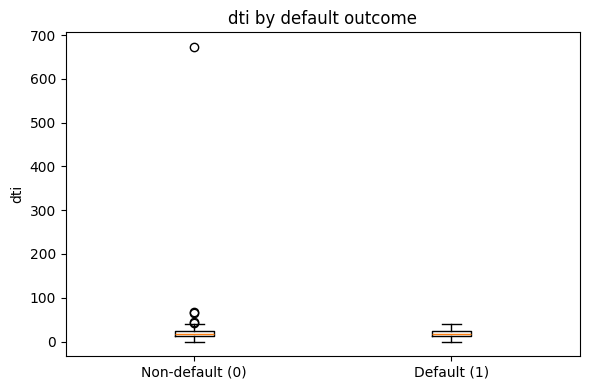

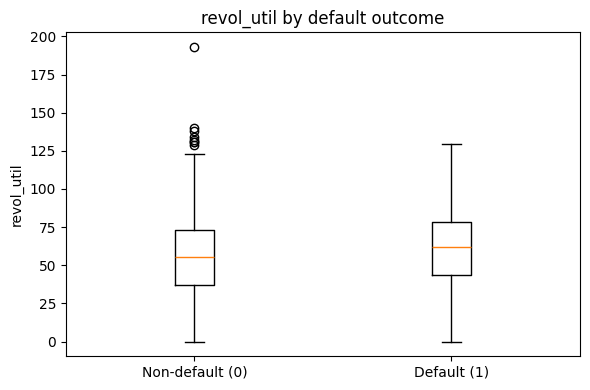

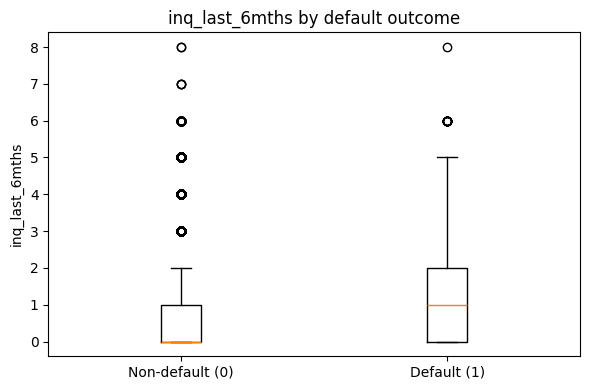

In [14]:
dt_to_plot = ['int_rate', 'dti', 'revol_util', 'inq_last_6mths']
for f in dt_to_plot:
    rows = df.select(f, 'default_ind').filter(
        col(f).isNotNull() & col('default_ind').isNotNull()
    ).sample(0.1, seed=42).collect()

    def to_float(v):
        try: return float(v)
        except: return None

    vals_0 = [to_float(r[f]) for r in rows if r['default_ind'] == 0 and r[f] is not None]
    vals_1 = [to_float(r[f]) for r in rows if r['default_ind'] == 1 and r[f] is not None]
    vals_0 = [v for v in vals_0 if v is not None]
    vals_1 = [v for v in vals_1 if v is not None]

    plt.figure(figsize=(6, 4))
    plt.boxplot([vals_0, vals_1], tick_labels=['Non-default (0)', 'Default (1)'])
    plt.title(f'{f} by default outcome')
    plt.ylabel(f)
    plt.tight_layout()
    plt.show()

### Boxplots by Default Outcome
Side-by-side boxplots to see whether each feature actually separates the two classes.

In [15]:
from pyspark.sql.functions import mean

def plot_default_rate_by(cat_col, min_count=500, figsize=(8, 5), top_n=None):
    rows = (df.groupBy(cat_col)
              .agg(mean('default_ind').alias('default_rate'), count('*').alias('n'))
              .filter(col('n') >= min_count)
              .orderBy('default_rate', ascending=False)
              .collect())

    if top_n:
        rows = rows[:top_n]

    overall    = df.select(mean('default_ind')).first()[0]
    categories = [str(r[cat_col]) for r in rows]
    rates      = [r['default_rate'] for r in rows]
    ns         = [r['n'] for r in rows]

    plt.figure(figsize=figsize)
    bars = plt.barh(categories, rates)
    plt.axvline(overall, color='red', linestyle='--', label=f'Overall ({overall:.1%})')
    plt.xlabel('Default rate')
    plt.title(f'Default rate by {cat_col}')
    plt.gca().invert_yaxis()
    for bar, n in zip(bars, ns):
        plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
                 f' n={n:,}', va='center', fontsize=7)
    plt.legend()
    plt.tight_layout()
    plt.show()

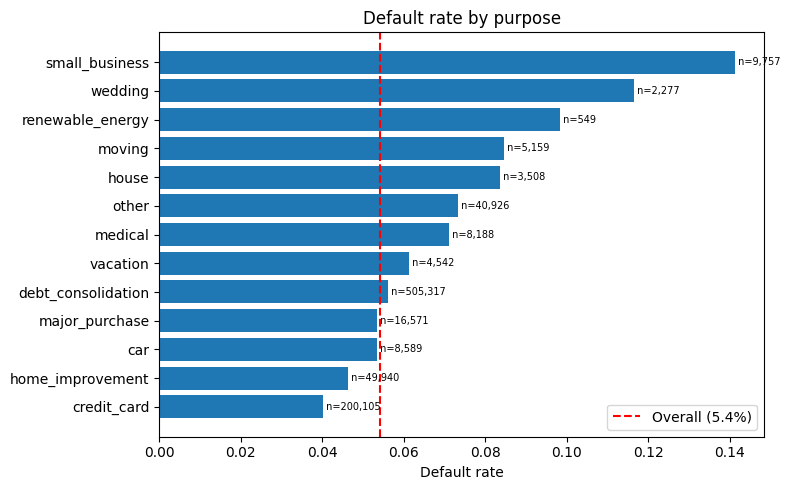

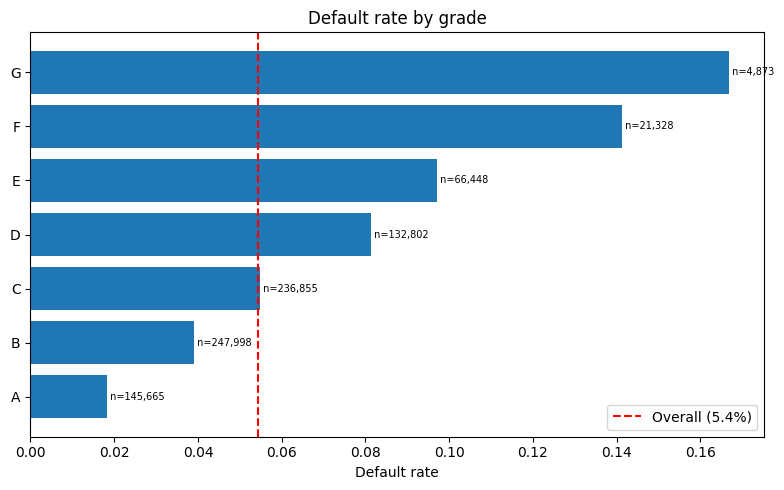

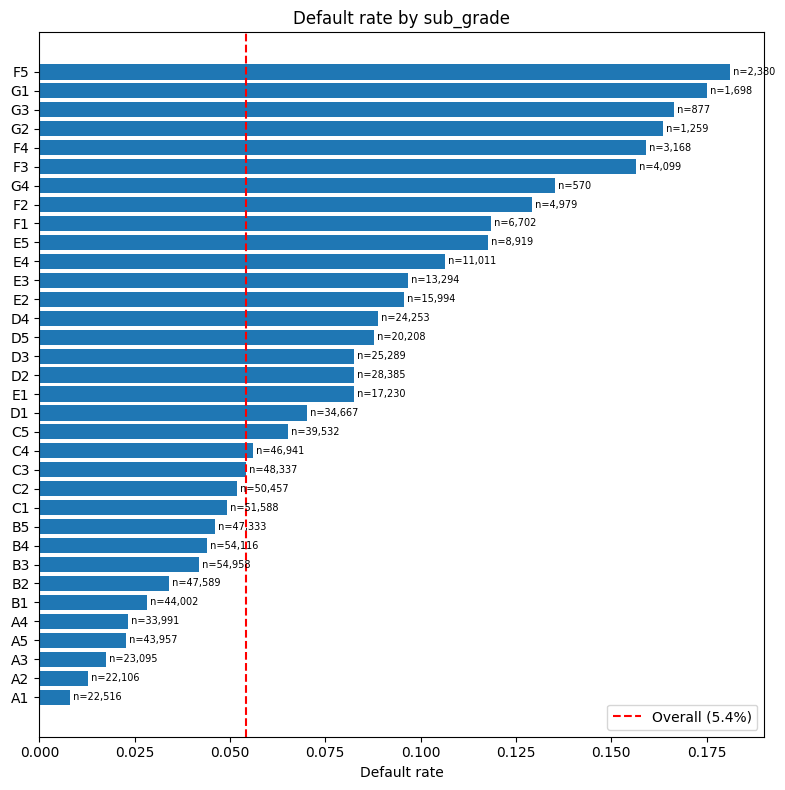

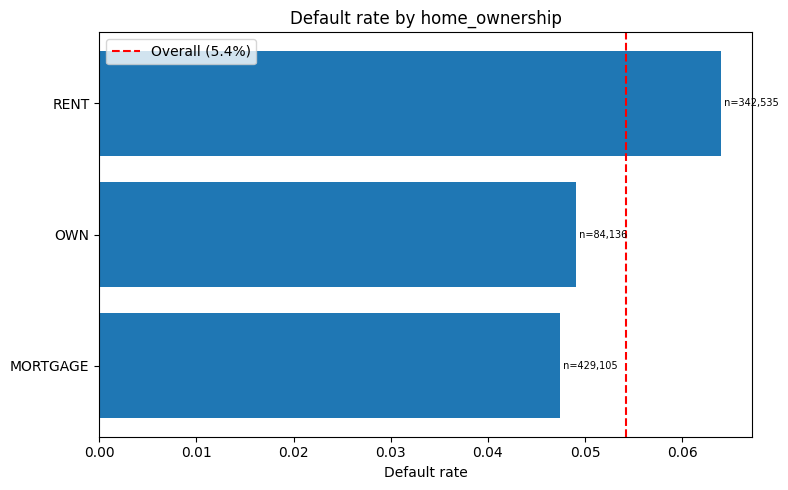

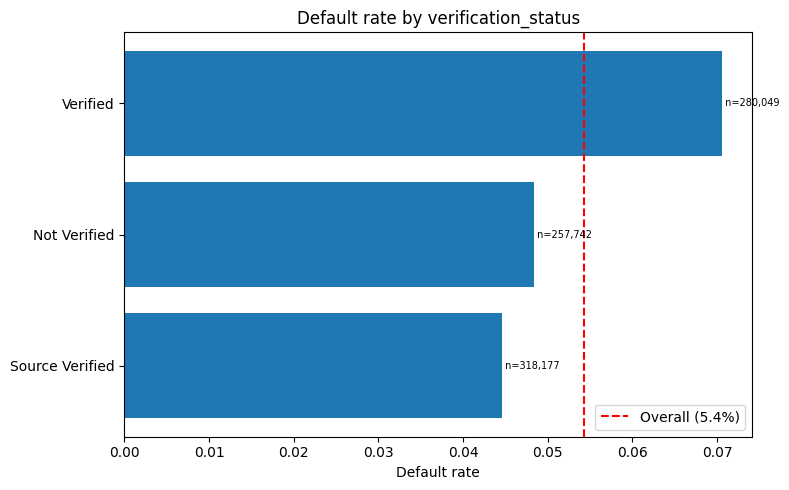

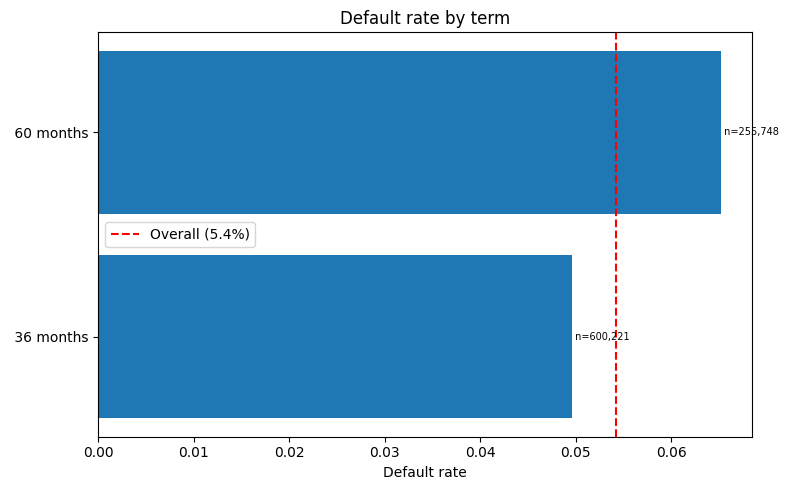

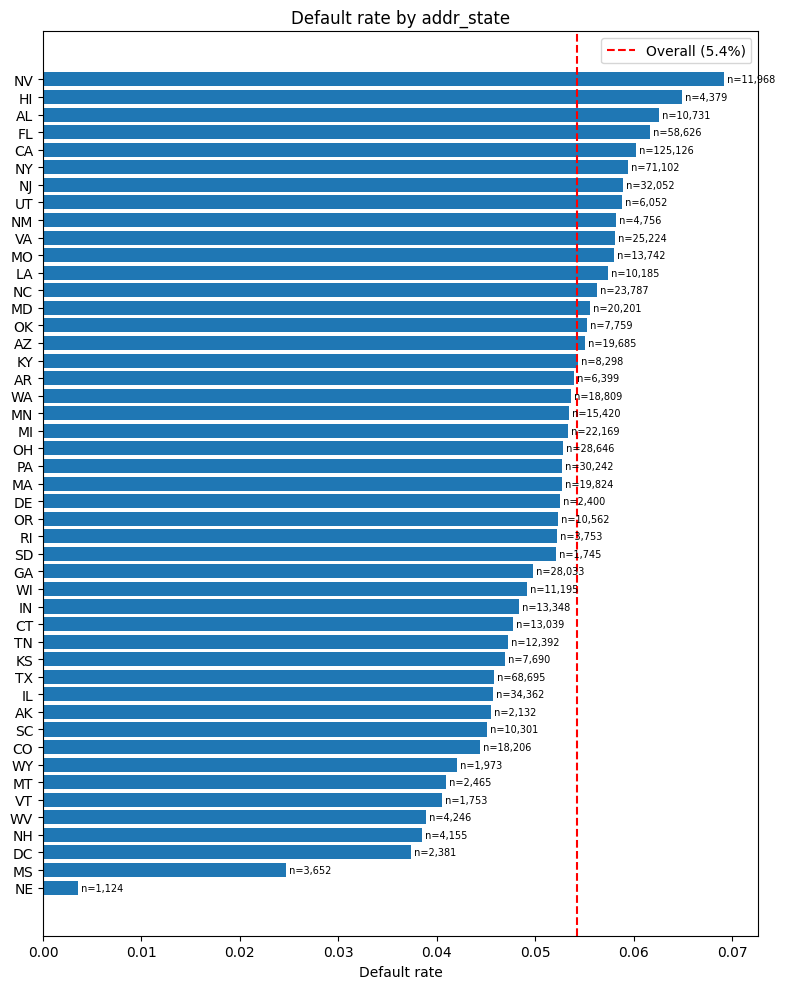

In [16]:
plot_default_rate_by('purpose')
plot_default_rate_by('grade')                  
plot_default_rate_by('sub_grade', figsize=(8, 8))
plot_default_rate_by('home_ownership')
plot_default_rate_by('verification_status')
plot_default_rate_by('term')                   
plot_default_rate_by('addr_state', figsize=(8, 10))

### Distribution of Numeric Features
Just checking the shape of each numeric feature — skewness, outliers, anything weird.

In [17]:
df = df.withColumn('annual_inc', expr("try_cast(annual_inc as double)"))
null = df.filter(col('annual_inc').isNull()).count()
print(f"Null: {null}")
df = df.na.drop(subset=['annual_inc'])

Null: 1


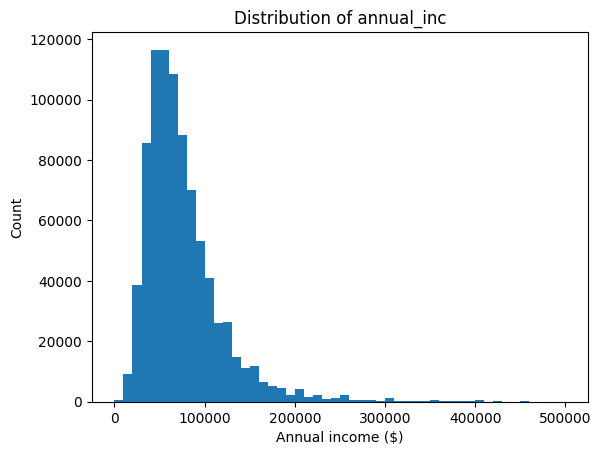

In [18]:
values = [r['annual_inc'] for r in df.select('annual_inc').filter(col('annual_inc') < 500000.0).collect()]
plt.hist(values, bins=50)
plt.xlabel('Annual income ($)')
plt.ylabel('Count')
plt.title('Distribution of annual_inc')
plt.show()

In [19]:
df = df.withColumn('dti', expr("try_cast(dti as double)"))
null = df.filter(col('dti').isNull()).count()
print(f"Null: {null}")

Null: 225


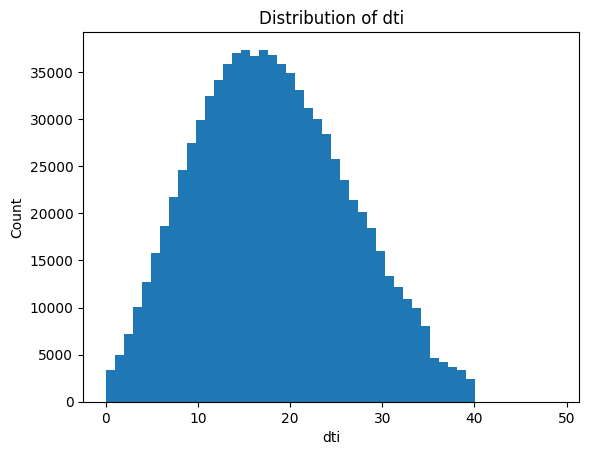

In [20]:
values = [r['dti'] for r in df.select('dti').filter(col('dti') < 50.0).collect()]
plt.hist(values, bins=50)
plt.xlabel('dti')
plt.ylabel('Count')
plt.title('Distribution of dti')
plt.show()

In [21]:
df = df.withColumn("int_rate", col("int_rate").cast("double"))


In [22]:
def plot_histogram(df, col_name, bins=50, clip_quantile=0.99, xlim=None, title=None):
    query = df.filter(col(col_name).isNotNull())
    if clip_quantile < 1.0:
        upper = query.approxQuantile(col_name, [clip_quantile], 0.01)[0]
        query = query.filter(col(col_name) <= upper)

    values = [r[col_name] for r in query.select(col_name).collect()]

    plt.figure(figsize=(8, 5))
    plt.hist(values, bins=bins, edgecolor='white', linewidth=0.3)
    plt.xlabel(col_name)
    plt.ylabel('Count')
    plt.title(title or f'Distribution of {col_name}')
    if xlim:
        plt.xlim(xlim)
    plt.tight_layout()
    plt.show()

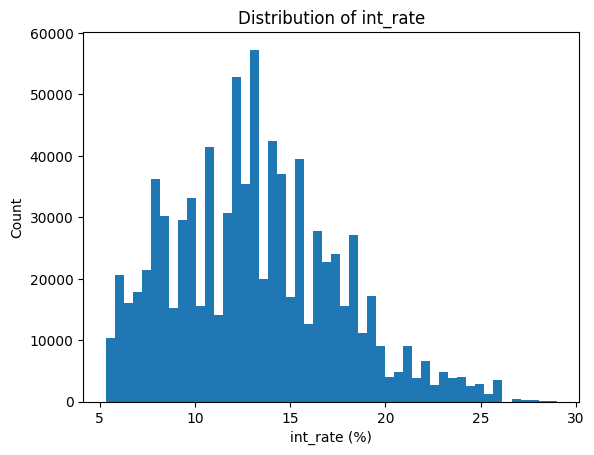

In [23]:
values = [r['int_rate'] for r in df.select('int_rate').filter(col('int_rate') < 100.0).collect()]
plt.hist(values, bins=50)
plt.xlabel('int_rate (%)')
plt.ylabel('Count')
plt.title('Distribution of int_rate')
plt.show()

In [24]:
df = df.withColumn('revol_util', expr("try_cast(revol_util as double)"))
null = df.filter(col('revol_util').isNull()).count()
print(f"Null: {null}")
df = df.na.drop(subset=['revol_util'])

Null: 512


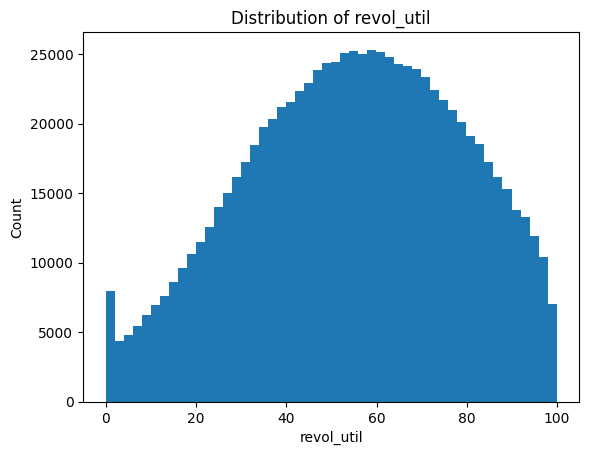

In [25]:
values = [r['revol_util'] for r in df.select('revol_util').filter(col('revol_util') < 100.0).collect()]
plt.hist(values, bins=50)
plt.xlabel('revol_util')
plt.ylabel('Count')
plt.title('Distribution of revol_util')
plt.show()

In [26]:
df = df.withColumn('loan_amnt', expr("try_cast(loan_amnt as double)"))
null = df.filter(col('loan_amnt').isNull()).count()
print(f"Null: {null}")

Null: 0


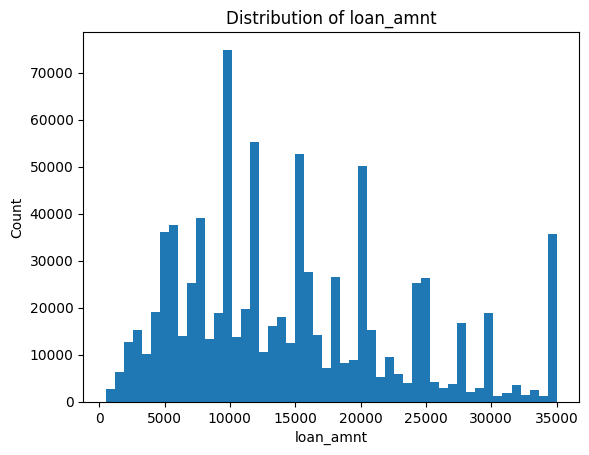

In [27]:
values = [r['loan_amnt'] for r in df.select('loan_amnt').filter(col('loan_amnt') < 100000).collect()]
plt.hist(values, bins=50)
plt.xlabel('loan_amnt')
plt.ylabel('Count')
plt.title('Distribution of loan_amnt')
plt.show()

### What we found from the EDA

Defaulters means the borrower fails to make timely payments, misses payments, or ceases making payments altogethe

**1. Target imbalance**
The dataset is heavily skewed (only 5.4% of loans defaulted). This means accuracy is basically useless as a metric since a model that always predicts "no default" would get ~94.6% anyway. We'll need to handle this with class weighting.

**2. Missing values**
A bunch of columns are more than 50% empty. Mostly the joint application fields and the IL/RV trade block (those were added to the dataset much later so older loans don't have them). We dropped those entirely since imputing 50%+ missing doesn't really make sense.

**3. Correlation heatmap**
The heatmap helped us catch the leakage columns. Things like `recoveries`, `out_prncp`, `total_pymnt` have really high correlations with `default_ind` which makes sense because they're literally recorded after default happens. We removed all of those before modelling.

**4. Boxplots**
- `int_rate` defaulters have noticeably higher interest rates (median ~15% vs ~12%). The IQRs don't overlap too much so this feature actually separates the classes reasonably well.
- `dti` basically the same distribution for both groups. Not a useful discriminator on its own.
- `revol_util` defaulters trend slightly higher (median ~60% vs ~56%) but the overlap is heavy. Weak signal.
- `inq_last_6mths` defaulters had more recent credit inquiries (median 1 vs 0). Makes sense and people seeking more credit right before defaulting.
- `annual_inc` defaulters earn about $7k less on average but there's massive overlap, so income alone isn't enough to separate them.

**5. Default rate by category**
- `grade` / `sub_grade` by far the strongest signal. A-grade borrowers default ~1.7% of the time, G-grade ~16.6%. Clean monotonic trend, which makes sense since LC built the grade system for exactly this.
- `purpose` small business loans default the most (14.2%), credit card consolidation the least (4%). About a 3.5x spread.
- `term` 60-month loans default more than 36-month (6.5% vs 4.9%). Longer duration = more exposure.
- `home_ownership` renters default slightly more than mortgage holders. Not a huge difference though.
- `verification_status` weirdly, verified income borrowers default *more* than unverified ones. Probably because LC tends to verify people who already look risky.
- `addr_state` some variation by state but nothing dramatic. Probably not worth including as a top feature.

**6. Distribution shapes**
- `annual_inc` heavily right-skewed, some extreme outliers. Needs log transform for linear models.
- `dti` roughly bell-shaped, capped around 40 (LC rejects higher DTI at application stage).
- `int_rate` multi-modal because it reflects the grade pricing tiers.
- `revol_util` bimodal, with spikes near 0% (people who pay in full) and around 50-60% (typical LC borrower carrying credit card debt).
- `loan_amnt` spiky at round numbers ($5k, $10k, etc.) which is just how people request loans.

## Data Cleaning

Based on what we found in the EDA, we now clean up the dataset before modelling. The main things to do are dropping leakage and useless columns, parsing some string fields, capping outliers, and imputing the remaining nulls.

Steps:
1. Drop leakage, redundant, and near-useless columns
2. Remove rows where the target is null
3. Parse string fields (percentages, dates, emp_length, etc.)
4. Cap outliers and add log_annual_inc
5. Check what nulls are left
6. Impute remaining nulls
7. Save the cleaned output

### Step 1 - Drop columns we don't want

We remove three groups:
- **Leakage columns**: anything recorded after the loan defaults (`recoveries`, `out_prncp`, `total_pymnt`, etc.). Using these would be cheating — the model would essentially already know the answer.
- **Near-useless**: identifiers (`id`, `member_id`), constants (`policy_code`, `pymnt_plan`), free text fields (`desc`, `emp_title`), and redundant fields (`funded_amnt` which is basically the same as `loan_amnt`).
- **Too sparse to use**: joint application fields (~99% null), the IL/RV trade block (~97% null), and `mths_since_last_*` (51-85% null).

In [28]:
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType, DoubleType

useless_cols = [
    'policy_code', 'pymnt_plan',
    'id', 'member_id', 'url',
    'desc', 'emp_title', 'title',
    'annual_inc_joint', 'dti_joint', 'verification_status_joint',
    'il_util', 'open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m',
    'mths_since_rcnt_il', 'total_bal_il',
    'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util',
    'inq_fi', 'total_cu_tl', 'inq_last_12m', 'total_rev_hi_lim',
    'mths_since_last_record', 'mths_since_last_major_derog', 'mths_since_last_delinq',
    'funded_amnt', 'funded_amnt_inv',
    'zip_code',
]

leakage_cols = [
    'recoveries', 'collection_recovery_fee',
    'out_prncp', 'out_prncp_inv',
    'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'last_pymnt_amnt', 'last_pymnt_d', 'next_pymnt_d',
    'last_fico_range_high', 'last_fico_range_low',
    'last_credit_pull_d',
    'loan_status',
]

cols_to_drop = [c for c in (useless_cols + leakage_cols) if c in df.columns]
df = df.drop(*cols_to_drop)
print(f"After Step 1: {len(df.columns)} columns (dropped {len(cols_to_drop)})")

After Step 1: 29 columns (dropped 44)


### Step 2 - Drop rows with no target

Can't train on rows where we don't know if the loan defaulted or not. Only about 158 rows affected.

In [29]:
before = df.count()
df = df.filter(F.col('default_ind').isNotNull())
after = df.count()
print(f"Dropped {before - after:,} rows with null default_ind")
df.groupBy('default_ind').count().orderBy('default_ind').show()

Dropped 158 rows with null default_ind
+-----------+------+
|default_ind| count|
+-----------+------+
|          0|808911|
|          1| 46387|
+-----------+------+



### Step 3 — Parse strings to numbers

A few columns came in as strings when they should be numeric:
- `int_rate` and `revol_util` had percent signs then strip and cast to double
- `term` was "36 months" / "60 months" extract just the number
- `emp_length` had values like "< 1 year", "10+ years" mapped to integers 0-10
- `issue_d` and `earliest_cr_line` are date strings and we convert them to a single derived feature `cr_history_years` (how long the borrower has had credit) and drop the raw dates

In [30]:

df = df.withColumn('int_rate',
    F.regexp_replace(F.col('int_rate').cast('string'), '%', '').cast(DoubleType()))
df = df.withColumn('revol_util',
    F.regexp_replace(F.col('revol_util').cast('string'), '%', '').cast(DoubleType()))

df = df.withColumn('term',
    F.regexp_extract(F.col('term'), r'(\d+)', 1).cast(IntegerType()))

df = df.withColumn('emp_length',
    F.when(F.col('emp_length') == '< 1 year', 0)
     .when(F.col('emp_length') == '10+ years', 10)
     .when(F.col('emp_length') == 'n/a', None)
     .otherwise(F.regexp_extract(F.col('emp_length'), r'(\d+)', 1).cast(IntegerType())))

df = df.withColumn('_issue_date', F.to_date(F.col('issue_d'), 'dd-MM-yyyy'))
df = df.withColumn('_earliest_cr', F.to_date(F.col('earliest_cr_line'), 'dd-MM-yyyy'))
df = df.withColumn('cr_history_years',
    F.round(F.datediff(F.col('_issue_date'), F.col('_earliest_cr')) / 365.25, 1))
df = df.drop('issue_d', 'earliest_cr_line', '_issue_date', '_earliest_cr')

to_numeric = [
    'annual_inc', 'dti', 'loan_amnt', 'installment',
    'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal',
    'total_acc', 'collections_12_mths_ex_med', 'acc_now_delinq',
    'tot_coll_amt', 'tot_cur_bal',
]
for c in to_numeric:
    if c in df.columns:
        df = df.withColumn(c, F.expr(f"try_cast({c} as double)"))

print("Step 3 complete - string fields parsed to numeric")

Step 3 complete - string fields parsed to numeric


### Step 4 - Outlier capping and log transform

A few columns had extreme values that would mess up linear and neural models:
- `revol_util` capped at 100 (some rows had values above 100 which is basically a data entry error)
- `dti` capped at 50 (values above that are sentinel codes for "not calculable")
- `annual_inc` capped at the 99th percentile (~$250k) and some self-reported incomes were clearly wrong ($9M+)
- Added `log_annual_inc` as an extra feature for models that prefer normally distributed inputs

In [31]:
df = df.withColumn('revol_util',
    F.when(F.col('revol_util') > 100, 100.0).otherwise(F.col('revol_util')))

df = df.withColumn('dti',
    F.when(F.col('dti') > 50, 50.0).otherwise(F.col('dti')))
p99 = df.selectExpr("percentile_approx(annual_inc, 0.99, 10000)").first()[0]
df = df.withColumn('annual_inc',
    F.when(F.col('annual_inc') > p99, p99).otherwise(F.col('annual_inc')))
print(f"Capped annual_inc at p99 = ${p99:,.0f}, dti at 50")

df = df.withColumn('log_annual_inc', F.log1p(F.col('annual_inc')))
print("Created log_annual_inc for linear/NN models")

Capped annual_inc at p99 = $250,000, dti at 50
Created log_annual_inc for linear/NN models


### Step 5 - Check remaining nulls

After all the dropping and parsing, we recheck which columns still have missing values and how many. Anything left should be small enough to impute.

In [32]:
total = df.count()
missing_exprs = []
for c, t in df.dtypes:
    if t == 'string':
        cond = F.col(c).isNull() | (F.col(c) == '')
    else:
        cond = F.col(c).isNull()
    missing_exprs.append((F.count(F.when(cond, c)) / total).alias(c))
missing_pct = df.select(missing_exprs).first().asDict()

print("\nColumns with any missing values:")
print(f"{'Column':35s} {'% missing':>10s}")
print('-' * 50)
for c, pct in sorted(missing_pct.items(), key=lambda x: -x[1]):
    if pct > 0:
        print(f"{c:35s} {pct*100:>9.2f}%")


Columns with any missing values:
Column                               % missing
--------------------------------------------------
tot_coll_amt                             7.83%
tot_cur_bal                              7.83%
emp_length                               5.03%
collections_12_mths_ex_med               0.01%


### Step 6 - Impute remaining nulls

For the handful of columns still with nulls:
- Numeric: fill with the column median (more robust than mean when distributions are skewed)
- Categorical: fill with the string 'unknown' so the model can treat missingness as its own category

In [33]:
numeric_types = ('int', 'bigint', 'double', 'float')
numeric_cols = [c for c, t in df.dtypes if t in numeric_types and c != 'default_ind']
categorical_cols = [c for c, t in df.dtypes if t == 'string']
print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

for c in numeric_cols:
    if missing_pct.get(c, 0) > 0:
        med = df.approxQuantile(c, [0.5], 0.01)
        if med:
            df = df.fillna({c: med[0]})

for c in categorical_cols:
    if missing_pct.get(c, 0) > 0:
        df = df.fillna({c: 'unknown'})

print("Step 6 complete - all nulls imputed")

Numeric columns: 20
Categorical columns: 8
Step 6 complete - all nulls imputed


### Step 7 - Save the cleaned data

Write out the cleaned dataset. This single file feeds both the Spark MLlib pipeline and the TensorFlow pipeline so both processes start from exactly the same cleaned matrix.

In [37]:
df_model = df

print(f"Final shape: {df_model.count():,} rows x {len(df_model.columns)} cols")
print(f"Default rate: {df_model.select(F.mean('default_ind')).first()[0]:.4f}  (expected ~0.054)")
print("\nFinal schema:")
for c, t in df_model.dtypes:
    print(f"  {c:30s} {t}")

df_model.toPandas().to_csv('cleaned_loan_data.csv', index=False)
print("Saved cleaned_loan_data.csv")

Final shape: 855,298 rows x 29 cols
Default rate: 0.0542  (expected ~0.054)

Final schema:
  loan_amnt                      double
  term                           int
  int_rate                       double
  installment                    double
  grade                          string
  sub_grade                      string
  emp_length                     int
  home_ownership                 string
  annual_inc                     double
  verification_status            string
  purpose                        string
  addr_state                     string
  dti                            double
  delinq_2yrs                    double
  inq_last_6mths                 double
  open_acc                       double
  pub_rec                        double
  revol_bal                      double
  revol_util                     double
  total_acc                      double
  initial_list_status            string
  collections_12_mths_ex_med     double
  application_type               st

### Feature ranking summary - 7 most and 7 least relevant

Based on everything above, here's our ranking. We only consider pre-origination features for the "most relevant" list and the post-origination columns have higher raw correlations but they leak the target so they don't count.

**7 most relevant:**
- `sub_grade` / `grade` = monotonic default rate from 0.8% (A1) to 18.1% (G5). Strongest signal in the dataset.
- `int_rate` = numeric proxy for grade, clear boxplot separation, |corr| ≈ 0.16
- `purpose` = 3.5x default rate spread across categories (4% to 14%)
- `term` = 60-month loans default 33% more often than 36-month
- `inq_last_6mths` = higher median for defaulters, classic credit-seeking signal
- `revol_util` = defaulters trend higher, especially in the tail near 100%
- `verification_status` = counterintuitive but real: verified borrowers default more because LC verifies riskier applicants

**7 least relevant:**
- `policy_code`, `pymnt_plan` = basically constant across the whole dataset, no signal
- `annual_inc_joint`, `dti_joint`, `verification_status_joint` = ~99% null, only populated for joint applications
- The IL/RV trade block (12 columns) = ~97% null, added to LC's schema much later
- `mths_since_last_delinq`, `mths_since_last_record`, `mths_since_last_major_derog` = 51-85% null
- `desc`, `emp_title`, `title` = free text with 60k-290k unique values, no way to generalise
- `id`, `member_id` = just identifiers, zero predictive value
- `funded_amnt`, `funded_amnt_inv` = perfectly correlated with `loan_amnt` (r ≈ 1.0), completely redundant

**Note on dti:** We expected this to be a strong predictor but the boxplots and correlation (~0.004) show it barely differs between the two groups. We kept it in the model anyway since tree models can pick up non-linear thresholds that univariate stats miss.

**Note on FICO:** Not in this dataset. We use `sub_grade` and `int_rate` as proxies instead.